# Customer Churn Prediction Using Machine Learning

Dataset: WA_Fn-UseC_-Telco-Customer-Churn.csv (IBM Telco, Kaggle)  
Place the CSV in the same folder as this notebook before running.

## 1. Setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV, cross_val_score
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
    precision_recall_curve, roc_curve
)

import shap
from scipy.stats import randint, uniform

pd.set_option('display.max_columns', None)
SEED = 42
np.random.seed(SEED)

## 2. Data Loading

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

## 3. Data Cleaning

In [5]:
# TotalCharges is read as object due to blank strings
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop the customer ID — no predictive value
df.drop(columns=['customerID'], inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('Missing values after conversion:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nChurn rate: {df["Churn"].mean():.3f}  ({df["Churn"].sum()} churned / {len(df)} total)')

Missing values after conversion:
TotalCharges    11
dtype: int64

Churn rate: 0.265  (1869 churned / 7043 total)


## 4. Exploratory Data Analysis (EDA)

### 4.1 Target variable distribution

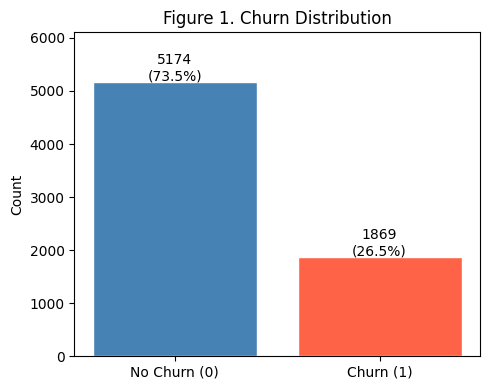

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['Churn'].value_counts()
bars = ax.bar(['No Churn (0)', 'Churn (1)'], counts.values,
              color=['steelblue', 'tomato'], edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax.set_ylabel('Count')
ax.set_title('Figure 1. Churn Distribution')
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.savefig('fig1_churn_distribution.png', dpi=150)
plt.show()

The dataset is imbalanced: 26.5% of customers churned. Class imbalance handling is required to prevent models from defaulting to the majority class.

### 4.2 Numerical feature distributions

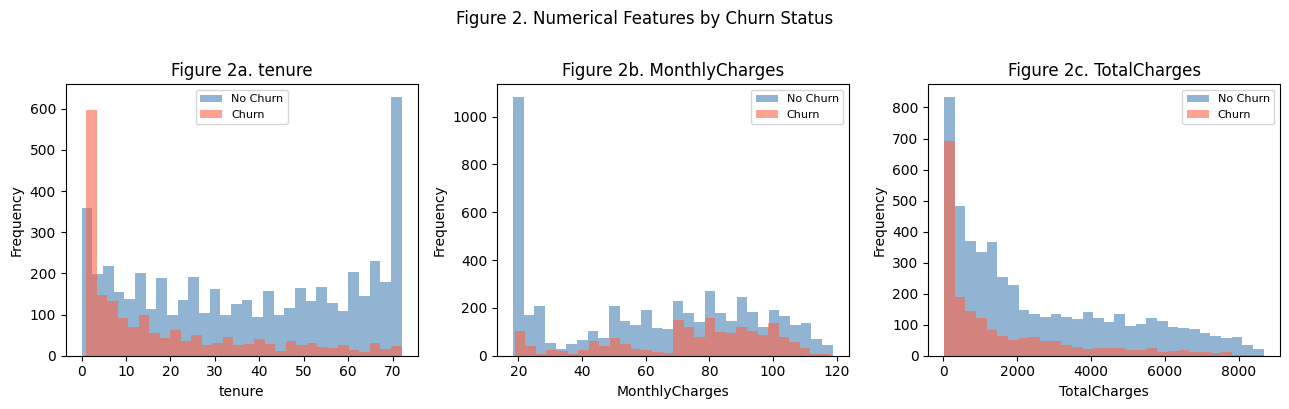

In [7]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, num_cols):
    df[df['Churn']==0][col].dropna().plot.hist(
        ax=ax, bins=30, alpha=0.6, color='steelblue', label='No Churn')
    df[df['Churn']==1][col].dropna().plot.hist(
        ax=ax, bins=30, alpha=0.6, color='tomato', label='Churn')
    ax.set_title(f'Figure 2{chr(97+num_cols.index(col))}. {col}')
    ax.set_xlabel(col)
    ax.legend(fontsize=8)
plt.suptitle('Figure 2. Numerical Features by Churn Status', y=1.01)
plt.tight_layout()
plt.savefig('fig2_numerical_distributions.png', dpi=150)
plt.show()

**Key observations:**  
- Churners cluster at short tenure (0–12 months). Long-tenure customers are predominately retained.  
- Churners show higher monthly charges, suggesting price sensitivity.  
- TotalCharges is right-skewed and correlated with tenure.

### 4.3 Correlation matrix

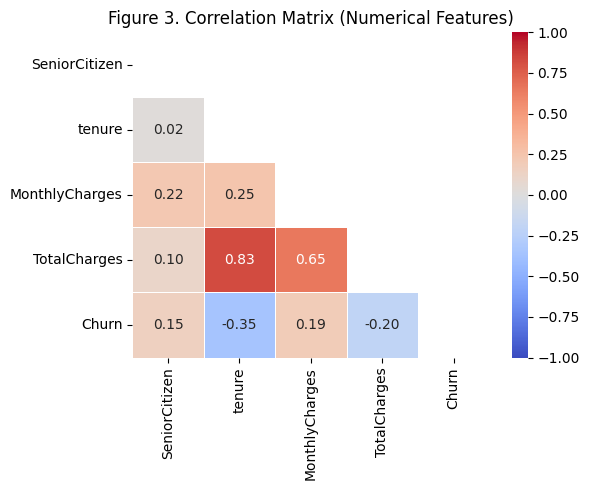

In [8]:
corr_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(df[corr_cols].corr(), dtype=bool))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, mask=mask, linewidths=0.5)
ax.set_title('Figure 3. Correlation Matrix (Numerical Features)')
plt.tight_layout()
plt.savefig('fig3_correlation_matrix.png', dpi=150)
plt.show()

Tenure and TotalCharges are strongly positively correlated (expected — spend accumulates over time). Churn is negatively correlated with tenure (r = −0.35) and TotalCharges, and mildly positively correlated with MonthlyCharges.

### 4.4 Key categorical features vs. churn

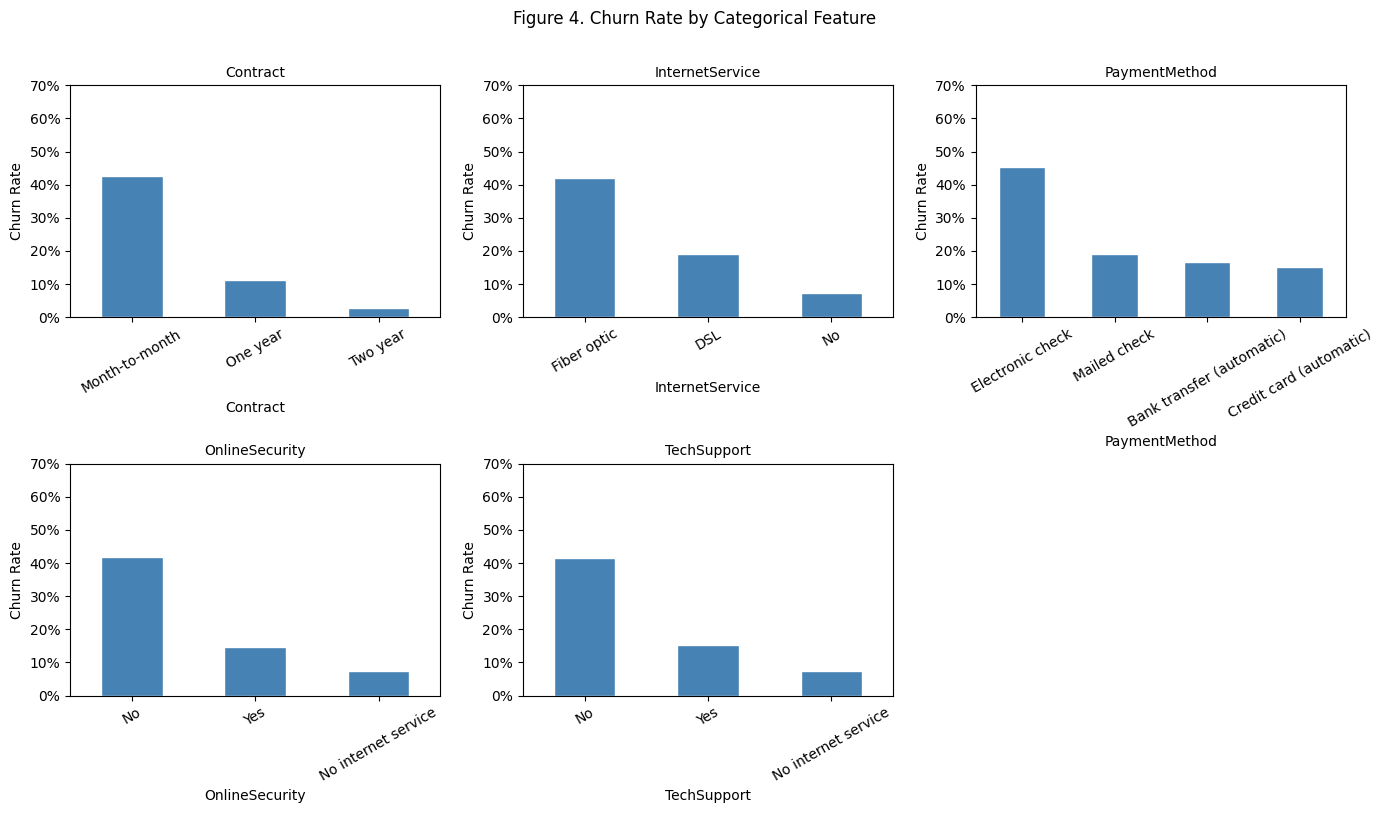

In [9]:
cat_focus = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_focus):
    churn_rates = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rates.plot.bar(ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_ylim(0, 0.7)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

axes[-1].axis('off')  # hide unused subplot
fig.suptitle('Figure 4. Churn Rate by Categorical Feature', y=1.01)
plt.tight_layout()
plt.savefig('fig4_categorical_churn_rates.png', dpi=150)
plt.show()

Month-to-month contracts have by far the highest churn rate (Approximately 43%). Fibre optic customers churn more than DSL customers, possibly due to higher monthly charges. Customers without online security or tech support churn at roughly double the rate of those with these add-ons.

### 4.5 Tenure vs. churn — boxplot

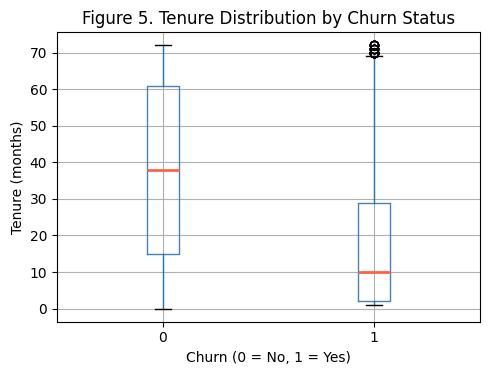

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
df.boxplot(column='tenure', by='Churn', ax=ax,
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='tomato', linewidth=2))
ax.set_xlabel('Churn (0 = No, 1 = Yes)')
ax.set_ylabel('Tenure (months)')
ax.set_title('Figure 5. Tenure Distribution by Churn Status')
plt.suptitle('')  # suppress pandas default title
plt.tight_layout()
plt.savefig('fig5_tenure_boxplot.png', dpi=150)
plt.show()

Churners have a median tenure of about 10 months vs. ~38 months for retained customers, confirming tenure is the single strongest churn predictor.

## 5. Preprocessing

In [11]:
X = df.drop(columns=['Churn'])
y = df['Churn']

num_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = [c for c in X.columns if c not in num_features]

print('Numerical features:', num_features)
print('Categorical features:', cat_features)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [12]:
# Stratified 60/20/20 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f'Train: {X_train.shape[0]} rows | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')
print(f'Churn rate — train: {y_train.mean():.3f} | val: {y_val.mean():.3f} | test: {y_test.mean():.3f}')

Train: 4225 rows | Val: 1409 | Test: 1409
Churn rate — train: 0.265 | val: 0.265 | test: 0.265


In [13]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

print('Preprocessor configured.')

Preprocessor configured.


SMOTE is applied **only inside the training pipeline** to prevent synthetic samples from leaking into validation or test sets.

## 6. Modelling

### 6.1 Model definitions and hyperparameter search spaces

RandomizedSearchCV is used rather than GridSearchCV to explore broader search spaces efficiently (Bergstra & Bengio, 2012). AUC-PR (average precision) is used as the scoring metric — it is more informative than recall alone on imbalanced datasets because it penalises both missed churners (low recall) and excessive false positives (low precision) simultaneously.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = 'average_precision'   # AUC-PR: better than raw recall on imbalanced data
N_ITER   = 50                   # randomised search iterations

model_specs = {
    'logistic_regression': {
        'clf': LogisticRegression(max_iter=2000, random_state=SEED, solver='lbfgs'),
        'params': {
            'clf__C': uniform(0.001, 10),
            'clf__class_weight': [None, 'balanced']
        }
    },
    'decision_tree': {
        'clf': DecisionTreeClassifier(random_state=SEED),
        'params': {
            'clf__max_depth': randint(3, 20),
            'clf__min_samples_split': randint(2, 50),
            'clf__min_samples_leaf': randint(1, 30),
            'clf__class_weight': [None, 'balanced']
        }
    },
    'random_forest': {
        'clf': RandomForestClassifier(random_state=SEED, n_jobs=-1),
        'params': {
            'clf__n_estimators': randint(100, 500),
            'clf__max_depth': [None] + list(range(5, 25)),
            'clf__min_samples_split': randint(2, 20),
            'clf__min_samples_leaf': randint(1, 15),
            'clf__max_features': ['sqrt', 'log2', 0.5],
            'clf__class_weight': [None, 'balanced']
        }
    },
    'xgboost': {
        'clf': XGBClassifier(
            eval_metric='logloss', random_state=SEED,
            use_label_encoder=False, n_jobs=-1
        ),
        'params': {
            'clf__n_estimators': randint(100, 500),
            'clf__max_depth': randint(3, 12),
            'clf__learning_rate': uniform(0.01, 0.3),
            'clf__subsample': uniform(0.6, 0.4),
            'clf__colsample_bytree': uniform(0.5, 0.5),
            'clf__reg_alpha': uniform(0, 1),
            'clf__reg_lambda': uniform(0.5, 2),
            'clf__scale_pos_weight': [1, 2.77]  # 2.77 ≈ neg/pos ratio
        }
    }
}

print('Model specifications ready.')

Model specifications ready.


### 6.2 Training with randomised hyperparameter search

In [15]:
fitted_models = {}
best_params   = {}

for name, spec in model_specs.items():
    print(f'Tuning {name}...')

    pipe = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=SEED)),
        ('clf', spec['clf'])
    ])

    search = RandomizedSearchCV(
        pipe, spec['params'],
        n_iter=N_ITER, scoring=SCORING,
        cv=cv, refit=True,
        random_state=SEED, n_jobs=-1, verbose=0
    )
    search.fit(X_train, y_train)

    fitted_models[name] = search.best_estimator_
    best_params[name]   = search.best_params_
    print(f'  Best CV AUC-PR: {search.best_score_:.4f} | params: {search.best_params_}\n')

print('All models tuned.')

Tuning logistic_regression...
  Best CV AUC-PR: 0.6566 | params: {'clf__C': np.float64(0.008787658410143284), 'clf__class_weight': 'balanced'}

Tuning decision_tree...
  Best CV AUC-PR: 0.5936 | params: {'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__min_samples_leaf': 24, 'clf__min_samples_split': 12}

Tuning random_forest...
  Best CV AUC-PR: 0.6554 | params: {'clf__class_weight': None, 'clf__max_depth': 12, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 14, 'clf__min_samples_split': 18, 'clf__n_estimators': 151}

Tuning xgboost...
  Best CV AUC-PR: 0.6620 | params: {'clf__colsample_bytree': np.float64(0.5866471600354228), 'clf__learning_rate': np.float64(0.05693111280132582), 'clf__max_depth': 4, 'clf__n_estimators': 195, 'clf__reg_alpha': np.float64(0.5492266647061205), 'clf__reg_lambda': np.float64(1.9291918454001247), 'clf__scale_pos_weight': 2.77, 'clf__subsample': np.float64(0.9738455989358838)}

All models tuned.


## 7. Evaluation

### 7.1 Metrics on validation and test sets

The test set was kept **completely unseen** during model selection; only the validation set was used for comparison and model selection. The test set is used here only for final reporting.

In [16]:
def evaluate(model, X, y, threshold=0.5):
    proba = model.predict_proba(X)[:, 1]
    pred  = (proba >= threshold).astype(int)
    return {
        'Accuracy':  round(accuracy_score(y, pred), 4),
        'Precision': round(precision_score(y, pred, zero_division=0), 4),
        'Recall':    round(recall_score(y, pred), 4),
        'F1':        round(f1_score(y, pred), 4),
        'AUC-ROC':   round(roc_auc_score(y, proba), 4),
        'AUC-PR':    round(roc_auc_score(y, proba, average='weighted'), 4)
    }

rows = []
for name, model in fitted_models.items():
    val_m  = evaluate(model, X_val,  y_val)
    test_m = evaluate(model, X_test, y_test)
    rows.append({'Model': name, 'Set': 'Validation', **val_m})
    rows.append({'Model': name, 'Set': 'Test',       **test_m})

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

              Model        Set  Accuracy  Precision  Recall     F1  AUC-ROC  AUC-PR
logistic_regression Validation    0.7530     0.5226  0.8048 0.6337   0.8544  0.8544
logistic_regression       Test    0.7431     0.5104  0.7861 0.6189   0.8281  0.8281
      decision_tree Validation    0.7651     0.5466  0.6738 0.6036   0.8165  0.8165
      decision_tree       Test    0.7459     0.5165  0.6711 0.5837   0.8009  0.8009
      random_forest Validation    0.7899     0.5823  0.7380 0.6509   0.8570  0.8570
      random_forest       Test    0.7665     0.5468  0.7032 0.6152   0.8278  0.8278
            xgboost Validation    0.7317     0.4968  0.8396 0.6243   0.8529  0.8529
            xgboost       Test    0.7303     0.4952  0.8342 0.6215   0.8224  0.8224


In [17]:
# Wide format for easy comparison
pivot = results_df.pivot(index='Model', columns='Set',
                          values=['Accuracy','Precision','Recall','F1','AUC-ROC'])
pivot.columns = [f'{m} ({s})' for m, s in pivot.columns]
pivot.round(4)

,Accuracy (Test),Accuracy (Validation),Precision (Test),Precision (Validation),Recall (Test),Recall (Validation),F1 (Test),F1 (Validation),AUC-ROC (Test),AUC-ROC (Validation)
Model,,,,,,,,,,
decision_tree,0.7459,0.7651,0.5165,0.5466,0.6711,0.6738,0.5837,0.6036,0.8009,0.8165
logistic_regression,0.7431,0.7530,0.5104,0.5226,0.7861,0.8048,0.6189,0.6337,0.8281,0.8544
random_forest,0.7665,0.7899,0.5468,0.5823,0.7032,0.7380,0.6152,0.6509,0.8278,0.8570
xgboost,0.7303,0.7317,0.4952,0.4968,0.8342,0.8396,0.6215,0.6243,0.8224,0.8529


### 7.2 Model comparison bar chart

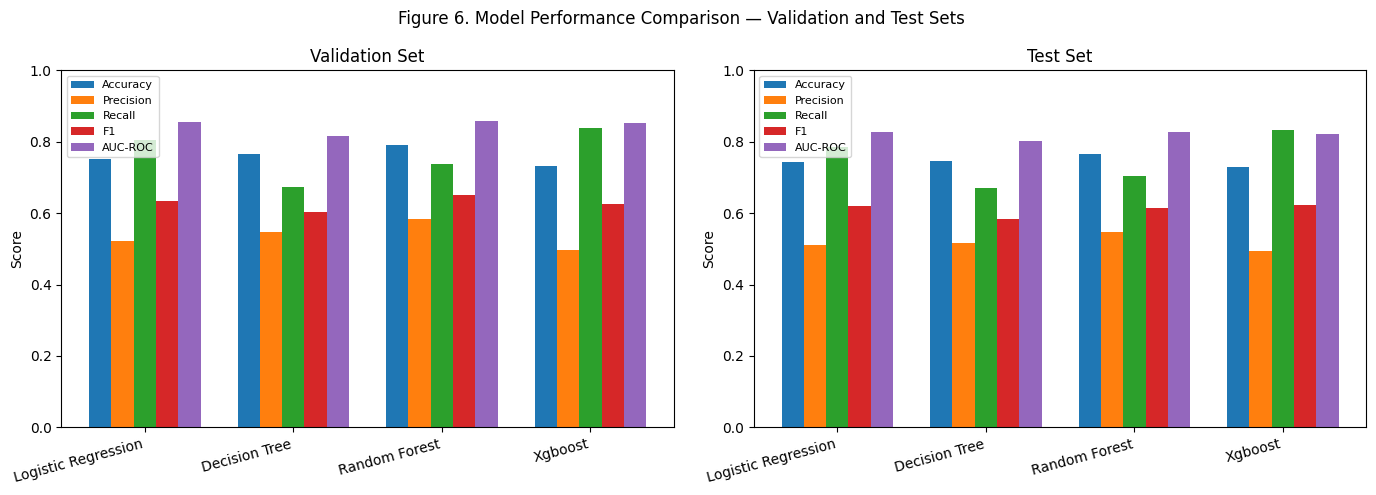

In [18]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
model_names = list(fitted_models.keys())
x = np.arange(len(model_names))
width = 0.15

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax_idx, split in enumerate(['Validation', 'Test']):
    subset = results_df[results_df['Set'] == split]
    ax = axes[ax_idx]
    for i, metric in enumerate(metrics_to_plot):
        vals = [subset[subset['Model']==m][metric].values[0] for m in model_names]
        ax.bar(x + i*width, vals, width, label=metric)
    ax.set_xticks(x + 2*width)
    ax.set_xticklabels([m.replace('_', ' ').title() for m in model_names], rotation=15, ha='right')
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Score')
    ax.set_title(f'{split} Set')
    ax.legend(fontsize=8)

fig.suptitle('Figure 6. Model Performance Comparison — Validation and Test Sets')
plt.tight_layout()
plt.savefig('fig6_model_comparison.png', dpi=150)
plt.show()

### 7.3 ROC curves

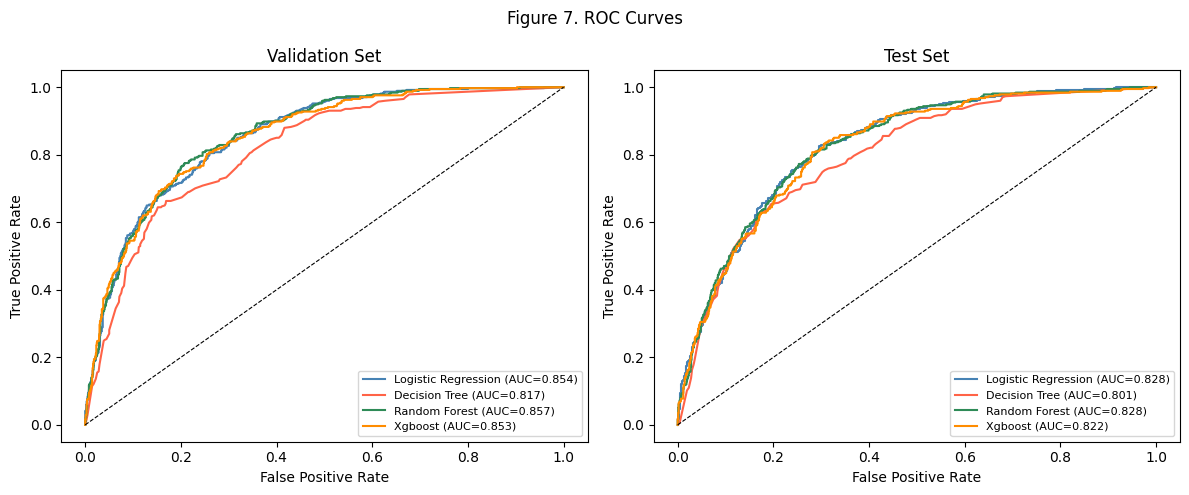

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

for ax, (X_eval, y_eval, title) in zip(
    axes,
    [(X_val, y_val, 'Validation'), (X_test, y_test, 'Test')]
):
    for (name, model), col in zip(fitted_models.items(), colors):
        fpr, tpr, _ = roc_curve(y_eval, model.predict_proba(X_eval)[:, 1])
        auc = roc_auc_score(y_eval, model.predict_proba(X_eval)[:, 1])
        ax.plot(fpr, tpr, color=col,
                label=f"{name.replace('_',' ').title()} (AUC={auc:.3f})")
    ax.plot([0,1],[0,1], 'k--', linewidth=0.8)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{title} Set')
    ax.legend(fontsize=8)

fig.suptitle('Figure 7. ROC Curves')
plt.tight_layout()
plt.savefig('fig7_roc_curves.png', dpi=150)
plt.show()

### 7.4 Precision–Recall curves

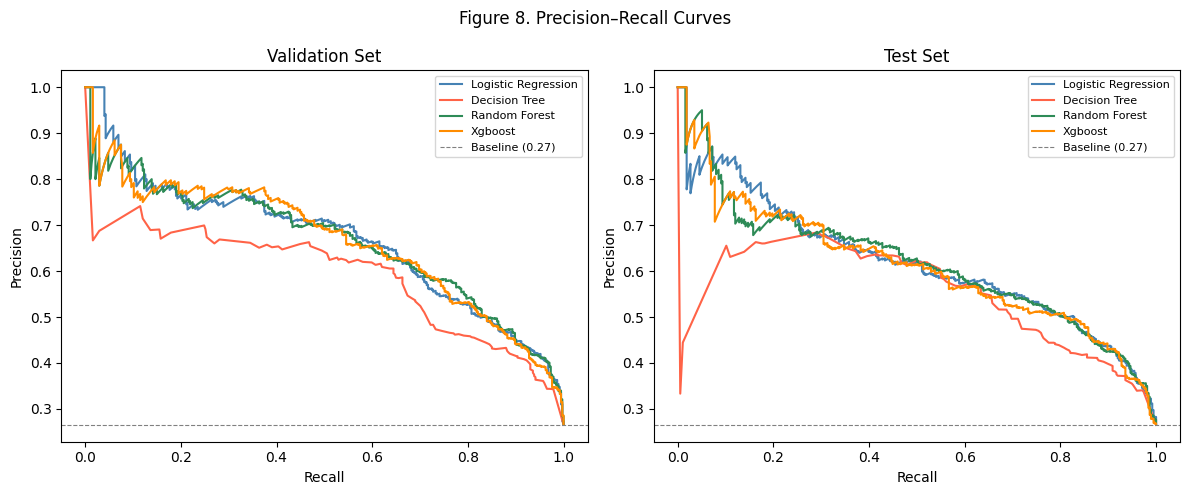

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (X_eval, y_eval, title) in zip(
    axes,
    [(X_val, y_val, 'Validation'), (X_test, y_test, 'Test')]
):
    for (name, model), col in zip(fitted_models.items(), colors):
        prec, rec, _ = precision_recall_curve(
            y_eval, model.predict_proba(X_eval)[:, 1])
        ap = roc_auc_score(y_eval, model.predict_proba(X_eval)[:, 1])
        ax.plot(rec, prec, color=col,
                label=f"{name.replace('_',' ').title()}")
    baseline = y_eval.mean()
    ax.axhline(baseline, color='grey', linestyle='--',
               linewidth=0.8, label=f'Baseline ({baseline:.2f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'{title} Set')
    ax.legend(fontsize=8)

fig.suptitle('Figure 8. Precision–Recall Curves')
plt.tight_layout()
plt.savefig('fig8_pr_curves.png', dpi=150)
plt.show()

### 7.5 Stability check — validation vs. test metrics

In [21]:
stability = {}
for name, model in fitted_models.items():
    v = evaluate(model, X_val,  y_val)
    t = evaluate(model, X_test, y_test)
    stability[name] = {
        'Recall_val':  v['Recall'],
        'Recall_test': t['Recall'],
        'Recall_drop': round(v['Recall'] - t['Recall'], 4),
        'F1_val':      v['F1'],
        'F1_test':     t['F1'],
        'F1_drop':     round(v['F1'] - t['F1'], 4)
    }

pd.DataFrame(stability).T

,Recall_val,Recall_test,Recall_drop,F1_val,F1_test,F1_drop
logistic_regression,0.8048,0.7861,0.0187,0.6337,0.6189,0.0148
decision_tree,0.6738,0.6711,0.0027,0.6036,0.5837,0.0199
random_forest,0.7380,0.7032,0.0348,0.6509,0.6152,0.0357
xgboost,0.8396,0.8342,0.0054,0.6243,0.6215,0.0028


Small differences between validation and test indicate good generalisation. A drop in recall > 0.05 between sets would suggest overfitting.

### 7.6 Confusion matrices — final model candidates

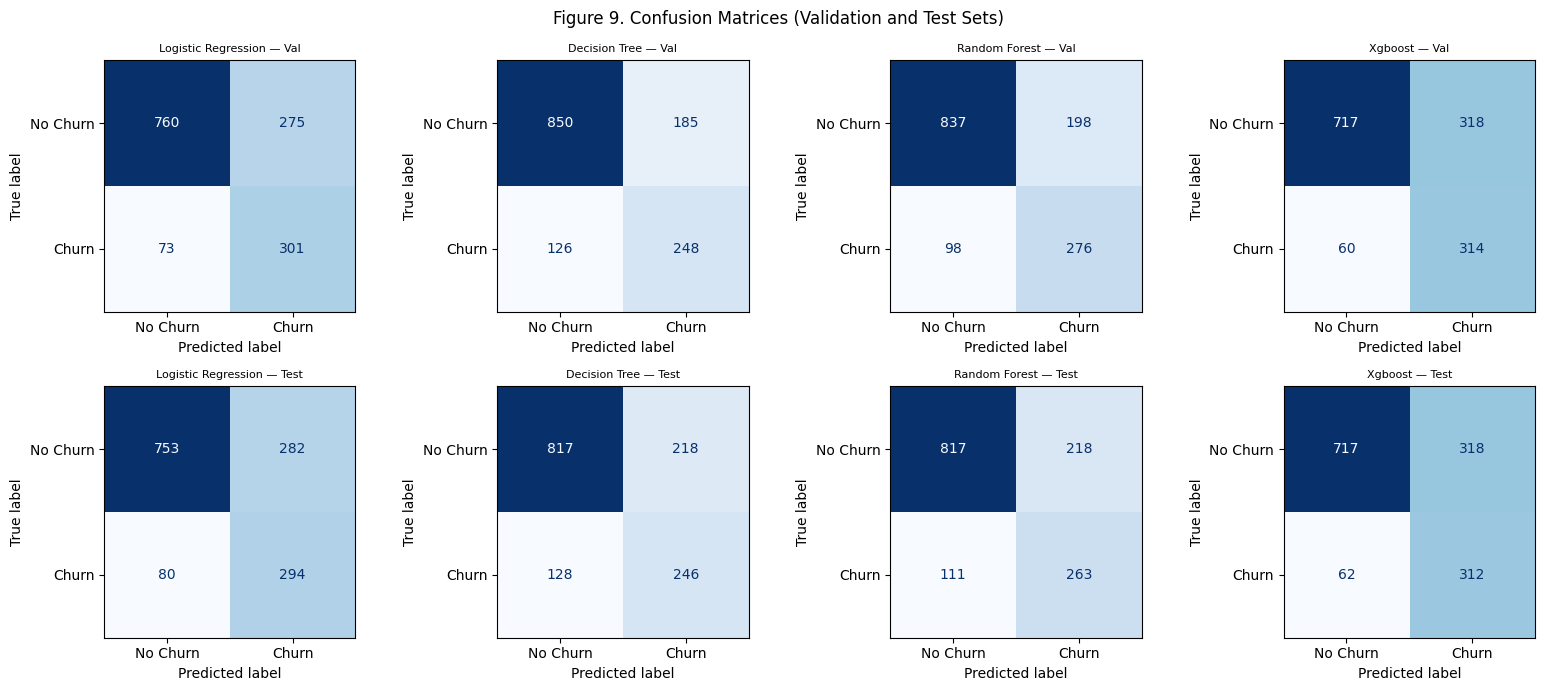

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for col_idx, (name, model) in enumerate(fitted_models.items()):
    for row_idx, (X_eval, y_eval, split) in enumerate(
        [(X_val, y_val, 'Val'), (X_test, y_test, 'Test')]
    ):
        preds = model.predict(X_eval)
        cm = confusion_matrix(y_eval, preds)
        disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
        disp.plot(ax=axes[row_idx][col_idx], colorbar=False, cmap='Blues')
        axes[row_idx][col_idx].set_title(
            f"{name.replace('_',' ').title()} — {split}", fontsize=8)

fig.suptitle('Figure 9. Confusion Matrices (Validation and Test Sets)')
plt.tight_layout()
plt.savefig('fig9_confusion_matrices.png', dpi=150)
plt.show()

### 7.7 Final model selection

In [23]:
# Select the model with the highest AUC-ROC on the validation set
val_results = results_df[results_df['Set']=='Validation'].set_index('Model')
best_model_name = val_results['AUC-ROC'].idxmax()
print(f'Selected model: {best_model_name}')
print(val_results.loc[best_model_name])

Selected model: random_forest
Set          Validation
Accuracy         0.7899
Precision        0.5823
Recall            0.738
F1               0.6509
AUC-ROC           0.857
AUC-PR            0.857
Name: random_forest, dtype: object


**Rationale:** AUC-ROC is used as the selection criterion because it evaluates discriminative power across all decision thresholds rather than at a single fixed cut-off, making it a more robust criterion on imbalanced datasets. If the business imposes a specific cost constraint (e.g., retention campaign budget), threshold tuning on the validation Precision–Recall curve should be performed before deployment.

## 8. SHAP Explainability

In [24]:
# Get feature names after preprocessing
fitted_preprocessor = fitted_models['random_forest'].named_steps['preprocessor']
ohe_names = fitted_preprocessor.named_transformers_['cat'] \
                .named_steps['encoder'].get_feature_names_out(cat_features).tolist()
feature_names = num_features + ohe_names
print(f'Total features after encoding: {len(feature_names)}')

Total features after encoding: 45


### 8.1 Random Forest — SHAP summary plot

In [ ]:
rf_model = fitted_models['random_forest']

# Transform validation data for SHAP
X_val_transformed = rf_model.named_steps['preprocessor'].transform(X_val)

explainer_rf = shap.TreeExplainer(rf_model.named_steps['clf'])
shap_values_rf = explainer_rf.shap_values(X_val_transformed)

# For binary classification sklearn RF, shap_values is a list [class0, class1]
sv = shap_values_rf[1] if isinstance(shap_values_rf, list) else shap_values_rf

fig, ax = plt.subplots(figsize=(8, 7))
shap.summary_plot(sv, X_val_transformed,
                  feature_names=feature_names,
                  max_display=15, show=False)
plt.title('Figure 10. SHAP Summary Plot — Random Forest (Validation Set)')
plt.tight_layout()
plt.savefig('fig10_shap_rf_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 XGBoost — SHAP summary plot

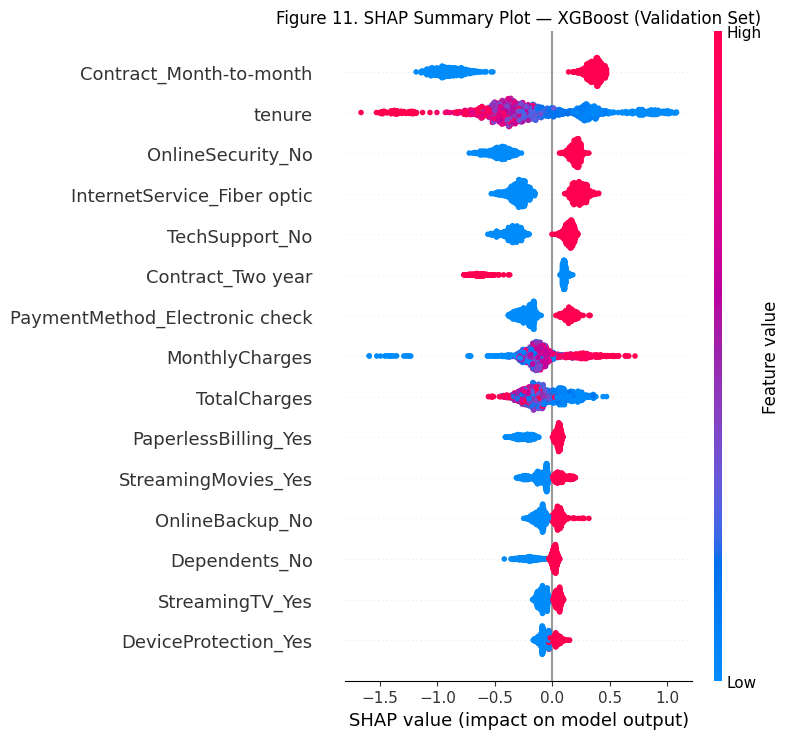

In [26]:
xgb_model = fitted_models['xgboost']
X_val_transformed_xgb = xgb_model.named_steps['preprocessor'].transform(X_val)

explainer_xgb = shap.TreeExplainer(xgb_model.named_steps['clf'])
shap_values_xgb = explainer_xgb.shap_values(X_val_transformed_xgb)

fig, ax = plt.subplots(figsize=(8, 7))
shap.summary_plot(shap_values_xgb, X_val_transformed_xgb,
                  feature_names=feature_names,
                  max_display=15, show=False)
plt.title('Figure 11. SHAP Summary Plot — XGBoost (Validation Set)')
plt.tight_layout()
plt.savefig('fig11_shap_xgb_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Logistic Regression — SHAP bar plot (top 15 features)

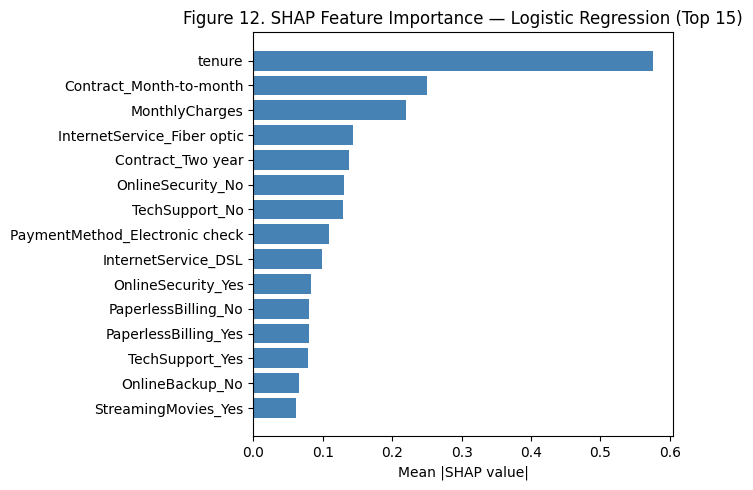

In [27]:
lr_model = fitted_models['logistic_regression']
X_val_transformed_lr = lr_model.named_steps['preprocessor'].transform(X_val)

explainer_lr = shap.LinearExplainer(
    lr_model.named_steps['clf'],
    X_val_transformed_lr,
    feature_names=feature_names
)
shap_values_lr = explainer_lr.shap_values(X_val_transformed_lr)

mean_abs_shap = np.abs(shap_values_lr).mean(axis=0)
top15_idx = np.argsort(mean_abs_shap)[-15:][::-1]
top15_names = [feature_names[i] for i in top15_idx]
top15_vals  = mean_abs_shap[top15_idx]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top15_names[::-1], top15_vals[::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Figure 12. SHAP Feature Importance — Logistic Regression (Top 15)')
plt.tight_layout()
plt.savefig('fig12_shap_lr_bar.png', dpi=150)
plt.show()

Across all three models, **tenure**, **MonthlyCharges**, **Contract_Month-to-month**, and **TotalCharges** consistently rank as the top churn drivers. This alignment between the Logistic Regression SHAP plot and the tree-based SHAP plots validates the consistency of the feature importance findings and increases confidence in the models' conclusions.

## 9. Business Insights

In [28]:
insights = {
    'Driver': [
        'Short tenure (< 12 months)',
        'Month-to-month contract',
        'High monthly charges',
        'Fibre optic without security add-ons',
        'Electronic check payment',
        'No tech support / online security'
    ],
    'Recommendation': [
        'Introduce onboarding loyalty discount for first 6 months',
        'Incentivise upgrade to 1- or 2-year contracts with price lock-in',
        'Offer tailored bundles to reduce perceived cost; proactive value communication',
        'Bundle security add-ons at discounted rate with fibre plans',
        'Prompt switch to auto-pay (credit card/bank transfer) with a small monthly credit',
        'Proactively offer free trial of support services to high-risk customers'
    ]
}
pd.DataFrame(insights)

,Driver,Recommendation
0,Short tenure (< 12 months),Introduce onboarding loyalty discount for firs...
1,Month-to-month contract,Incentivise upgrade to 1- or 2-year contracts ...
2,High monthly charges,Offer tailored bundles to reduce perceived cos...
3,Fibre optic without security add-ons,Bundle security add-ons at discounted rate wit...
4,Electronic check payment,Prompt switch to auto-pay (credit card/bank tr...
5,No tech support / online security,Proactively offer free trial of support servic...


## 10. Summary

In [29]:
final_summary = results_df.pivot(
    index='Model', columns='Set',
    values=['Recall', 'F1', 'AUC-ROC', 'Accuracy', 'Precision']
)
final_summary.columns = [f'{m} ({s})' for m, s in final_summary.columns]
print(final_summary.round(4).to_string())

                     Recall (Test)  Recall (Validation)  F1 (Test)  F1 (Validation)  AUC-ROC (Test)  AUC-ROC (Validation)  Accuracy (Test)  Accuracy (Validation)  Precision (Test)  Precision (Validation)
Model                                                                                                                                                                                                      
decision_tree               0.6711               0.6738     0.5837           0.6036          0.8009                0.8165           0.7459                 0.7651            0.5165                  0.5466
logistic_regression         0.7861               0.8048     0.6189           0.6337          0.8281                0.8544           0.7431                 0.7530            0.5104                  0.5226
random_forest               0.7032               0.7380     0.6152           0.6509          0.8278                0.8570           0.7665                 0.7899            0.5468     